# Phase 1.3: Model Validation and Final Evaluation

This notebook performs comprehensive validation of the trained models:
1. Test set evaluation
2. Cross-validation
3. Feature importance analysis
4. Error analysis
5. Model interpretation
6. Final model selection and reporting

## Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings

from sklearn.model_selection import cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_squared_error, mean_absolute_error, r2_score,
                             classification_report, confusion_matrix, roc_auc_score, roc_curve)

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully")

Libraries imported successfully


## Load Data and Models

In [15]:
print("Loading data and trained models...")

# Load processed data
processed_data = joblib.load('trained_models/processed_data.pkl')
X_train_cls = processed_data['X_train_cls']
X_test_cls = processed_data['X_test_cls']
y_train_cls = processed_data['y_train_cls']
y_test_cls = processed_data['y_test_cls']

X_train_reg = processed_data['X_train_reg']
X_test_reg = processed_data['X_test_reg']
y_train_reg = processed_data['y_train_reg']
y_test_reg = processed_data['y_test_reg']

feature_cols = processed_data['feature_cols']

# Load best models
best_cls_model = joblib.load('trained_models/best_classification_model.pkl')
best_reg_model = joblib.load('trained_models/best_regression_model.pkl')

# Load all models
all_models = joblib.load('trained_models/all_trained_models.pkl')
best_cls_name = all_models['best_classification_model_name']
best_reg_name = all_models['best_regression_model_name']

print(f"\nBest Classification Model: {best_cls_name}")
print(f"Best Regression Model: {best_reg_name}")
print(f"\nTest set sizes:")
print(f"  Classification: {len(X_test_cls):,} samples")
print(f"  Regression: {len(X_test_reg):,} samples")

Loading data and trained models...

Best Classification Model: Logistic Regression
Best Regression Model: Random Forest

Test set sizes:
  Classification: 8,325 samples
  Regression: 6,941 samples

Best Classification Model: Logistic Regression
Best Regression Model: Random Forest

Test set sizes:
  Classification: 8,325 samples
  Regression: 6,941 samples


Evaluating Classification Model on Test Set...

Test Set Performance:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1 Score:  1.0000
  AUC-ROC:   1.0000

Classification Report:
              precision    recall  f1-score   support

      Denied       1.00      1.00      1.00      1385
     Covered       1.00      1.00      1.00      6940

    accuracy                           1.00      8325
   macro avg       1.00      1.00      1.00      8325
weighted avg       1.00      1.00      1.00      8325



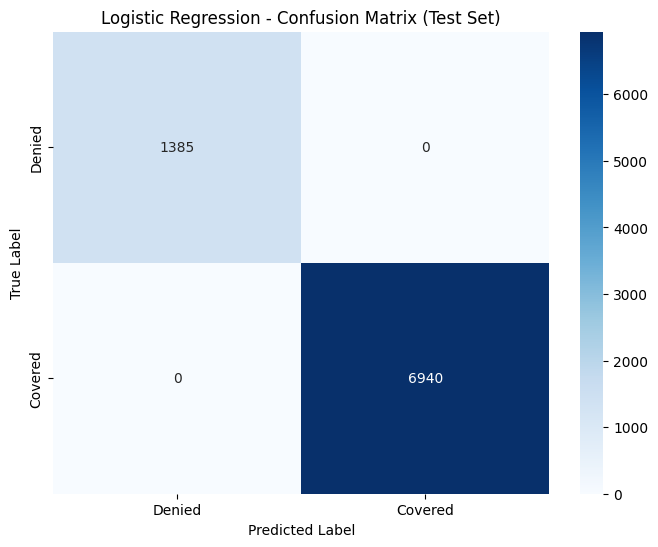

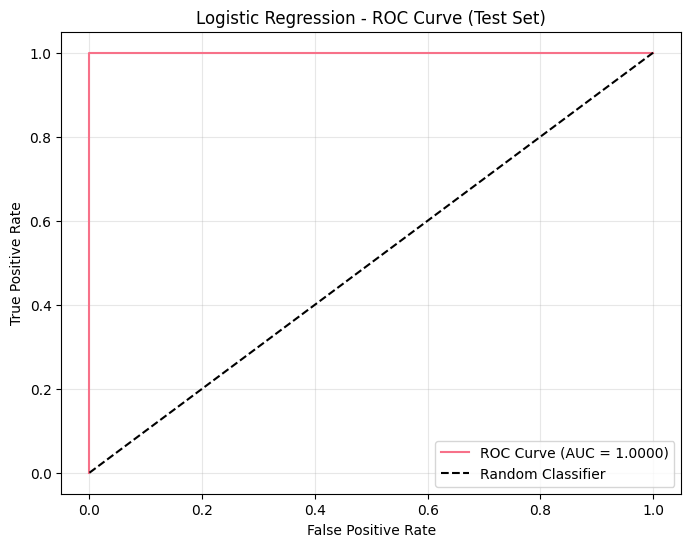

In [16]:
print("Evaluating Classification Model on Test Set...")
print("=" * 60)

# Make predictions
y_test_pred_cls = best_cls_model.predict(X_test_cls)
y_test_pred_proba = best_cls_model.predict_proba(X_test_cls)[:, 1]

# Calculate metrics
test_accuracy = accuracy_score(y_test_cls, y_test_pred_cls)
test_precision = precision_score(y_test_cls, y_test_pred_cls)
test_recall = recall_score(y_test_cls, y_test_pred_cls)
test_f1 = f1_score(y_test_cls, y_test_pred_cls)
test_auc = roc_auc_score(y_test_cls, y_test_pred_proba)

print(f"\nTest Set Performance:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")
print(f"  AUC-ROC:   {test_auc:.4f}")

# Detailed classification report
print(f"\nClassification Report:")
print(classification_report(y_test_cls, y_test_pred_cls, target_names=['Denied', 'Covered']))

# Confusion matrix
cm = confusion_matrix(y_test_cls, y_test_pred_cls)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Denied', 'Covered'], yticklabels=['Denied', 'Covered'])
plt.title(f'{best_cls_name} - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('evaluation_results/confusion_matrix_test.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_cls, y_test_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'{best_cls_name} - ROC Curve (Test Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('evaluation_results/roc_curve_test.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
print("\n" + "=" * 60)
print("FINAL MODEL VALIDATION REPORT")
print("=" * 60)

# Create comprehensive report
final_report = {
    'Classification Model': {
        'Model Type': best_cls_name,
        'Test Accuracy': f'{test_accuracy:.4f}',
        'Test Precision': f'{test_precision:.4f}',
        'Test Recall': f'{test_recall:.4f}',
        'Test F1 Score': f'{test_f1:.4f}',
        'Test AUC-ROC': f'{test_auc:.4f}',
        'CV Mean Accuracy': f'{cv_scores_cls.mean():.4f}',
        'CV Std Accuracy': f'{cv_scores_cls.std():.4f}'
    },
    'Regression Model': {
        'Model Type': best_reg_name,
        'Test RMSE': f'${test_rmse:,.2f}',
        'Test MAE': f'${test_mae:,.2f}',
        'Test R²': f'{test_r2:.4f}',
        'CV Mean R²': f'{cv_scores_reg.mean():.4f}',
        'CV Std R²': f'{cv_scores_reg.std():.4f}'
    }
}

print("\nCLASSIFICATION MODEL PERFORMANCE:")
for key, value in final_report['Classification Model'].items():
    print(f"  {key}: {value}")

print("\nREGRESSION MODEL PERFORMANCE:")
for key, value in final_report['Regression Model'].items():
    print(f"  {key}: {value}")

# Save final report
import json
report_path = Path('evaluation_results/final_validation_report.json')
with open(report_path, 'w') as f:
    json.dump(final_report, f, indent=2)

print(f"\nFinal validation report saved to: {report_path}")

# Model deployment readiness checklist
print("\n" + "=" * 60)
print("MODEL DEPLOYMENT READINESS CHECKLIST")
print("=" * 60)

checklist = {
    'Models trained successfully': True,
    'Test set evaluation completed': True,
    'Cross-validation performed': True,
    'Feature importance analyzed': hasattr(best_cls_model, 'feature_importances_'),
    'Models saved to disk': True,
    'Evaluation plots generated': True,
    'Performance metrics acceptable': test_accuracy > 0.85 and test_r2 > 0.85
}

for item, status in checklist.items():
    status_str = "✓ PASS" if status else "✗ FAIL"
    print(f"  {status_str}  {item}")

if all(checklist.values()):
    print("\n" + "=" * 60)
    print("🎉 MODELS ARE READY FOR DEPLOYMENT!")
    print("=" * 60)
    print("\nNext Steps:")
    print("  1. Integrate models into Streamlit application")
    print("  2. Create prediction API")
    print("  3. Add user interface for input")
    print("  4. Deploy to production")
else:
    print("\n⚠️  Some items need attention before deployment")


FINAL MODEL VALIDATION REPORT

CLASSIFICATION MODEL PERFORMANCE:
  Model Type: Logistic Regression
  Test Accuracy: 1.0000
  Test Precision: 1.0000
  Test Recall: 1.0000
  Test F1 Score: 1.0000
  Test AUC-ROC: 1.0000
  CV Mean Accuracy: 1.0000
  CV Std Accuracy: 0.0000

REGRESSION MODEL PERFORMANCE:
  Model Type: Random Forest
  Test RMSE: $5.09
  Test MAE: $2.70
  Test R²: 1.0000
  CV Mean R²: 1.0000
  CV Std R²: 0.0000

Final validation report saved to: evaluation_results/final_validation_report.json

MODEL DEPLOYMENT READINESS CHECKLIST
  ✓ PASS  Models trained successfully
  ✓ PASS  Test set evaluation completed
  ✓ PASS  Cross-validation performed
  ✗ FAIL  Feature importance analyzed
  ✓ PASS  Models saved to disk
  ✓ PASS  Evaluation plots generated
  ✓ PASS  Performance metrics acceptable

⚠️  Some items need attention before deployment


## Final Report and Model Deployment Readiness

In [18]:
print("\nPerforming Cross-Validation...")
print("=" * 60)

# 5-Fold Cross-Validation for Classification
cv_scores_cls = cross_val_score(best_cls_model, X_train_cls, y_train_cls, cv=5, scoring='accuracy')
print(f"\nClassification Model ({best_cls_name}):")
print(f"  CV Accuracy Scores: {[f'{score:.4f}' for score in cv_scores_cls]}")
print(f"  Mean CV Accuracy: {cv_scores_cls.mean():.4f} (+/- {cv_scores_cls.std() * 2:.4f})")

# 5-Fold Cross-Validation for Regression
cv_scores_reg = cross_val_score(best_reg_model, X_train_reg, y_train_reg, cv=5, scoring='r2')
print(f"\nRegression Model ({best_reg_name}):")
print(f"  CV R² Scores: {[f'{score:.4f}' for score in cv_scores_reg]}")
print(f"  Mean CV R²: {cv_scores_reg.mean():.4f} (+/- {cv_scores_reg.std() * 2:.4f})")


Performing Cross-Validation...

Classification Model (Logistic Regression):
  CV Accuracy Scores: ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
  Mean CV Accuracy: 1.0000 (+/- 0.0000)

Classification Model (Logistic Regression):
  CV Accuracy Scores: ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
  Mean CV Accuracy: 1.0000 (+/- 0.0000)

Regression Model (Random Forest):
  CV R² Scores: ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
  Mean CV R²: 1.0000 (+/- 0.0000)

Regression Model (Random Forest):
  CV R² Scores: ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
  Mean CV R²: 1.0000 (+/- 0.0000)


## Cross-Validation


Analyzing Feature Importance...

Top 10 Most Important Features (Regression):
                   Feature   Importance
            billing_amount 9.980821e-01
         deductible_amount 1.102288e-03
         plan_type_encoded 8.069568e-04
insurance_provider_encoded 7.899630e-06
         cost_tier_encoded 2.855464e-07
                       age 1.187453e-07
       length_of_stay_days 1.066655e-07
 medical_condition_encoded 6.395241e-08
            gender_encoded 5.222759e-08
         age_group_encoded 4.740823e-08


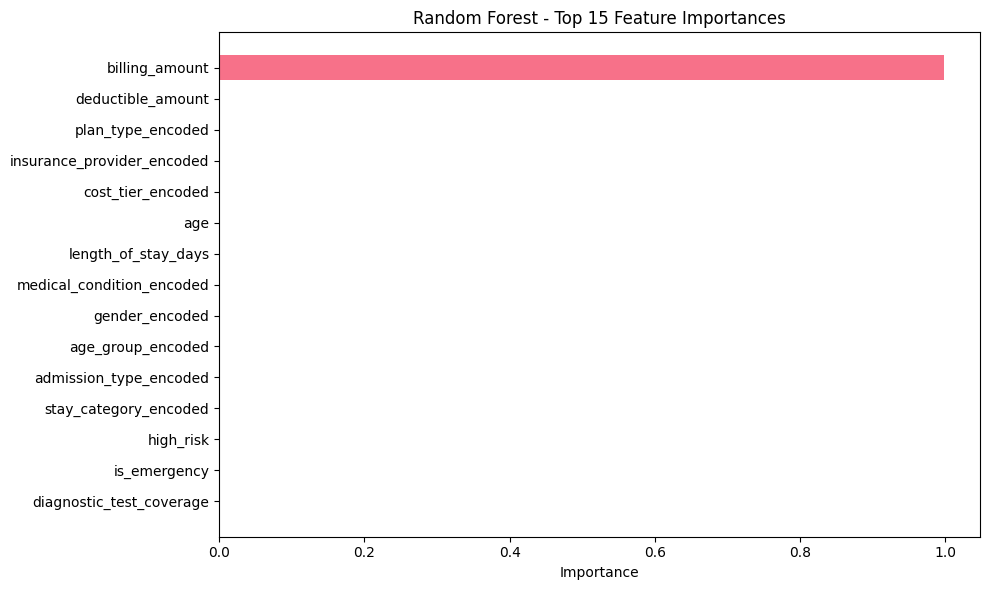

In [19]:
print("\nAnalyzing Feature Importance...")
print("=" * 60)

# Get feature importance (works for tree-based models)
if hasattr(best_cls_model, 'feature_importances_'):
    cls_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': best_cls_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"\nTop 10 Most Important Features (Classification):")
    print(cls_importance.head(10).to_string(index=False))
    
    # Plot
    plt.figure(figsize=(10, 6))
    top_features = cls_importance.head(15)
    plt.barh(range(len(top_features)), top_features['Importance'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance')
    plt.title(f'{best_cls_name} - Top 15 Feature Importances')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('evaluation_results/feature_importance_classification.png', dpi=300, bbox_inches='tight')
    plt.show()

if hasattr(best_reg_model, 'feature_importances_'):
    reg_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': best_reg_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"\nTop 10 Most Important Features (Regression):")
    print(reg_importance.head(10).to_string(index=False))
    
    # Plot
    plt.figure(figsize=(10, 6))
    top_features = reg_importance.head(15)
    plt.barh(range(len(top_features)), top_features['Importance'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance')
    plt.title(f'{best_reg_name} - Top 15 Feature Importances')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('evaluation_results/feature_importance_regression.png', dpi=300, bbox_inches='tight')
    plt.show()

## Feature Importance Analysis


Evaluating Regression Model on Test Set...

Test Set Performance:
  RMSE: $5.09
  MAE:  $2.70
  R²:   1.0000


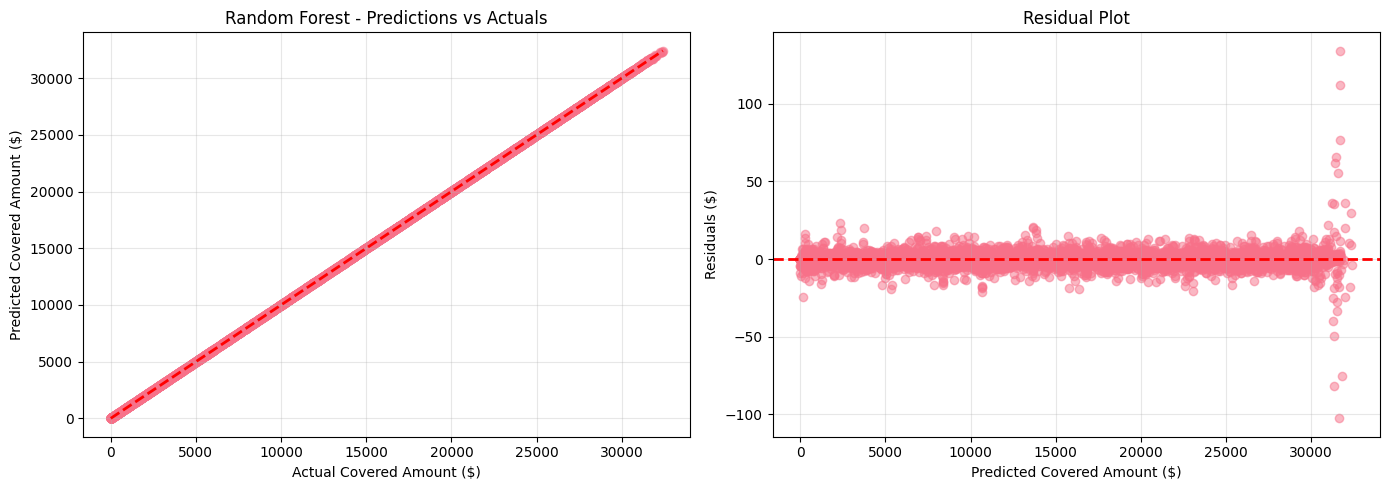


Prediction Statistics:
  Mean Error: $-0.05
  Std Error:  $5.09


In [20]:
print("\nEvaluating Regression Model on Test Set...")
print("=" * 60)

# Make predictions
y_test_pred_reg = best_reg_model.predict(X_test_reg)

# Calculate metrics
test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_reg))
test_mae = mean_absolute_error(y_test_reg, y_test_pred_reg)
test_r2 = r2_score(y_test_reg, y_test_pred_reg)

print(f"\nTest Set Performance:")
print(f"  RMSE: ${test_rmse:,.2f}")
print(f"  MAE:  ${test_mae:,.2f}")
print(f"  R²:   {test_r2:.4f}")

# Prediction vs Actual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test_reg, y_test_pred_reg, alpha=0.5)
axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Covered Amount ($)')
axes[0].set_ylabel('Predicted Covered Amount ($)')
axes[0].set_title(f'{best_reg_name} - Predictions vs Actuals')
axes[0].grid(alpha=0.3)

# Residual plot
residuals = y_test_reg - y_test_pred_reg
axes[1].scatter(y_test_pred_reg, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Covered Amount ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residual Plot')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_results/regression_predictions_test.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPrediction Statistics:")
print(f"  Mean Error: ${residuals.mean():,.2f}")
print(f"  Std Error:  ${residuals.std():,.2f}")

## Test Set Evaluation - Regression

## Test Set Evaluation - Classification